<a href="https://colab.research.google.com/github/achraftriki12/lab-3/blob/lab3-code/_lab3_Part1_TextVisualization_Classical_ipynb_triki_achraf.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
!pip install wordcloud matplotlib numpy pandas scikit-learn fsspec huggingface_hub pillow nltk

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from collections import Counter
import re
import string

import nltk
nltk.download('punkt', quiet=True)
nltk.download('stopwords', quiet=True)
nltk.download('wordnet', quiet=True)

from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

from wordcloud import WordCloud, STOPWORDS
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer

print("Setup complete!")

Setup complete!


## Part A: Loading and Exploring the 20 Newsgroups Dataset (15 min)

In [4]:
# Install if needed
!pip install datasets

# Imports
import pandas as pd
from datasets import load_dataset

# Load dataset from Hugging Face
dataset = load_dataset("SetFit/20_newsgroups")

# Convert to pandas DataFrame (train split)
df = pd.DataFrame(dataset['train'])

# Display info
print(f"Dataset shape: {df.shape}")
print(f"\nColumns: {df.columns.tolist()}")
print(f"\nLabel distribution:")
print(df['label_text'].value_counts())


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md:   0%|          | 0.00/734 [00:00<?, ?B/s]

Repo card metadata block was not found. Setting CardData to empty.


train.jsonl:   0%|          | 0.00/14.8M [00:00<?, ?B/s]

test.jsonl:   0%|          | 0.00/8.91M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/11314 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/7532 [00:00<?, ? examples/s]

Dataset shape: (11314, 3)

Columns: ['text', 'label', 'label_text']

Label distribution:
label_text
rec.sport.hockey            600
soc.religion.christian      599
rec.motorcycles             598
rec.sport.baseball          597
sci.crypt                   595
sci.med                     594
rec.autos                   594
sci.space                   593
comp.windows.x              593
comp.os.ms-windows.misc     591
sci.electronics             591
comp.sys.ibm.pc.hardware    590
misc.forsale                585
comp.graphics               584
comp.sys.mac.hardware       578
talk.politics.mideast       564
talk.politics.guns          546
alt.atheism                 480
talk.politics.misc          465
talk.religion.misc          377
Name: count, dtype: int64


In [6]:
print("Sample document:")
print("="*50)
print(f"Label: {df.iloc[0]['label_text']}")
print(f"Text (first 500 chars): {df.iloc[0]['text'][:500]}...")

Sample document:
Label: rec.autos
Text (first 500 chars): I was wondering if anyone out there could enlighten me on this car I saw
the other day. It was a 2-door sports car, looked to be from the late 60s/
early 70s. It was called a Bricklin. The doors were really small. In addition,
the front bumper was separate from the rest of the body. This is 
all I know. If anyone can tellme a model name, engine specs, years
of production, where this car is made, history, or whatever info you
have on this funky looking car, please e-mail....


## Exercise A.1: Select YOUR Categories

In [7]:
# Choose 3 categories
my_categories = [
    "rec.sport.hockey",
    "sci.space",
    "comp.graphics"
]

# Filter the dataset
df_filtered = df[df['label_text'].isin(my_categories)].copy()
df_filtered = df_filtered.reset_index(drop=True)

print(f"Selected categories: {my_categories}")
print(f"Filtered dataset size: {len(df_filtered)}")
print(f"\nDistribution:")
print(df_filtered['label_text'].value_counts())

Selected categories: ['rec.sport.hockey', 'sci.space', 'comp.graphics']
Filtered dataset size: 1777

Distribution:
label_text
rec.sport.hockey    600
sci.space           593
comp.graphics       584
Name: count, dtype: int64


I chose these three categories because they are quite different from each other, which makes the analysis more interesting. One is related to sports, another to science, and the last one to technology, so I expect the vocabulary to be very distinct in each case. For example, I think the hockey category will include words about games and teams, while the space category will have more scientific terms, and graphics will include technical computer-related words. I also chose them because they are topics I find interesting and easier to understand, which helps me better interpret the results.

## Part B: Text Preprocessing Function

In [8]:
import re
import string

def preprocess_text(text):
    """Basic text preprocessing."""

    # Lowercase
    text = text.lower()

    # Remove emails
    text = re.sub(r'\S+@\S+', '', text)

    # Remove URLs
    text = re.sub(r'http\S+|www\S+', '', text)

    # Remove numbers
    text = re.sub(r'\d+', '', text)

    # Remove punctuation
    text = text.translate(str.maketrans('', '', string.punctuation))

    # Remove extra whitespace
    text = re.sub(r'\s+', ' ', text).strip()

    return text


# Test
sample = "Hello! Check this: http://example.com. Email me at test@email.com. Price: $100."
print(f"Original: {sample}")
print(f"Cleaned:  {preprocess_text(sample)}")

Original: Hello! Check this: http://example.com. Email me at test@email.com. Price: $100.
Cleaned:  hello check this email me at price


# Exercise B.1: Improve the Preprocessing Function

In [11]:
import re
import string
from nltk.tokenize import word_tokenize
import nltk

nltk.download('punkt')
nltk.download('punkt_tab')
nltk.download('stopwords')
nltk.download('wordnet')

stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

def preprocess_text_advanced(text):
    """
    Advanced text preprocessing with stop words removal and lemmatization.
    """

    # Step 1: Basic cleaning
    text = text.lower()
    text = re.sub(r'\S+@\S+', '', text)           # remove emails
    text = re.sub(r'http\S+|www\S+', '', text)   # remove URLs
    text = re.sub(r'\d+', '', text)              # remove numbers
    text = text.translate(str.maketrans('', '', string.punctuation))
    text = re.sub(r'\s+', ' ', text).strip()

    # Step 2: Tokenize
    tokens = word_tokenize(text)

    # Step 3: Remove stop words
    tokens = [word for word in tokens if word not in stop_words]

    # Step 4: Lemmatize
    tokens = [lemmatizer.lemmatize(word) for word in tokens]

    # Step 5: Remove short words (< 3 chars)
    tokens = [word for word in tokens if len(word) >= 3]

    # Step 6: Join back
    return ' '.join(tokens)


# Test
sample = "The cats are running quickly towards the beautiful gardens. Email: test@mail.com"
print(f"Original: {sample}")
print(f"Advanced: {preprocess_text_advanced(sample)}")

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


Original: The cats are running quickly towards the beautiful gardens. Email: test@mail.com
Advanced: cat running quickly towards beautiful garden email


In [14]:
# Apply preprocessing to your filtered dataset
df_filtered['text_clean'] = df_filtered['text'].apply(preprocess_text_advanced)

# Show sample
print("Sample preprocessed document:")
print(df_filtered.iloc[0]['text_clean'][:300])

Sample preprocessed document:
weiteks addressphone number like get information chip


## Part C: Text Visualization

**C.1 Bar Chart: Top Words per Category**

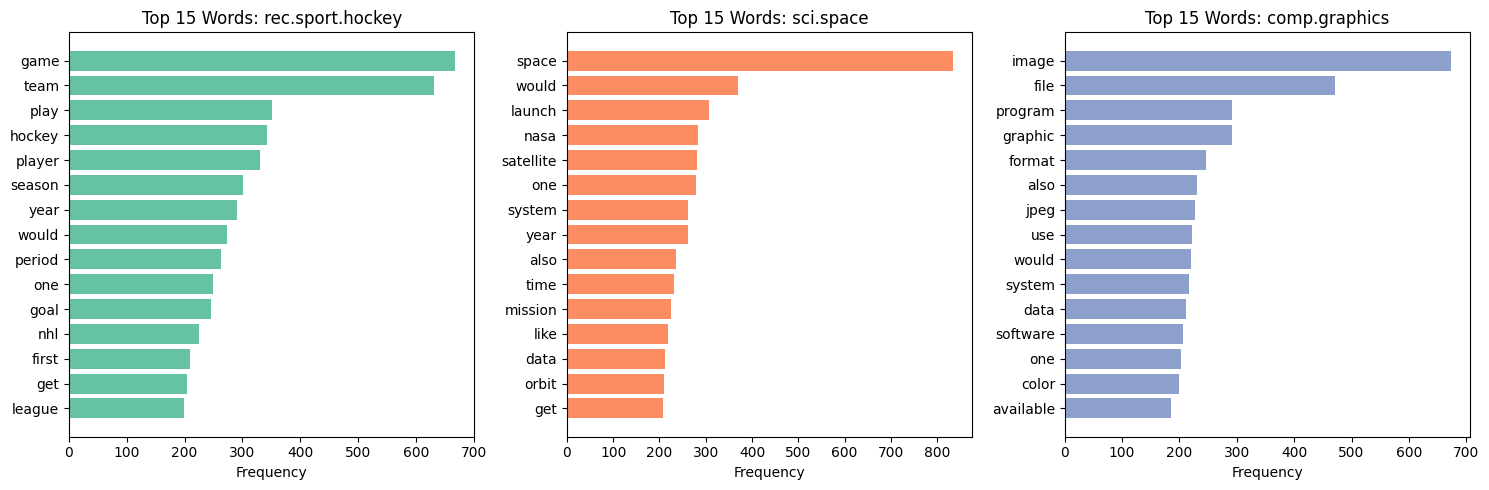

In [15]:
def get_top_words(texts, n=15):
    """Get the n most common words from a list of texts."""
    all_words = ' '.join(texts).split()
    word_counts = Counter(all_words)
    return word_counts.most_common(n)

# Get top words for each category
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for idx, category in enumerate(my_categories):
    texts = df_filtered[df_filtered['label_text'] == category]['text_clean'].tolist()
    top_words = get_top_words(texts, 15)

    words, counts = zip(*top_words)
    axes[idx].barh(words, counts, color=plt.cm.Set2(idx))
    axes[idx].set_title(f'Top 15 Words: {category}')
    axes[idx].invert_yaxis()
    axes[idx].set_xlabel('Frequency')

plt.tight_layout()
plt.savefig('top_words_by_category.png', dpi=150, bbox_inches='tight')
plt.show()

Category 1 (rec.sport.hockey):

Unique words: hockey, goal

Category 2 (sci.space):

Unique words: nasa, orbit

Category 3 (comp.graphics):

Unique words: image, jpeg

Shared words and explanation:
Some words like "system", "data", "one", and "would" appear across multiple categories. These words are quite general and can be used in many different contexts, whether discussing sports, space missions, or computer graphics. That is why they are shared between categories.

Topic guessing analysis:
Yes, it is possible to guess the topic of each category based on the top words. In the first category, words like "hockey", "goal", and "team" clearly indicate a sports context. In the second category, terms like "nasa", "launch", and "orbit" strongly suggest space and scientific discussions. In the third category, words such as "image", "jpeg", and "graphics" point to computer-related topics. The vocabulary alone gives a clear indication of each subject.

**C.2 Word Clouds**

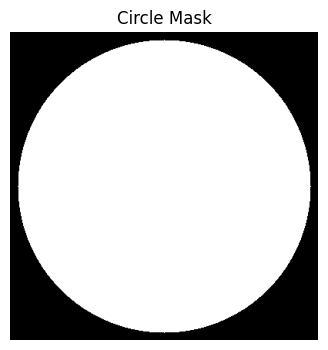

In [16]:
# Example: Creating a circular mask programmatically
# (You can replace this with your own image)

from PIL import Image

# Create a circular mask
def create_circle_mask(size=400):
    x = np.arange(0, size)
    y = np.arange(0, size)
    cx, cy = size // 2, size // 2
    r = size // 2 - 10
    mask = np.zeros((size, size), dtype=np.uint8)
    for i in x:
        for j in y:
            if (i - cx)**2 + (j - cy)**2 <= r**2:
                mask[j, i] = 255
    return mask

circle_mask = create_circle_mask(400)

# Show the mask
plt.figure(figsize=(4, 4))
plt.imshow(circle_mask, cmap='gray')
plt.title('Circle Mask')
plt.axis('off')
plt.show()

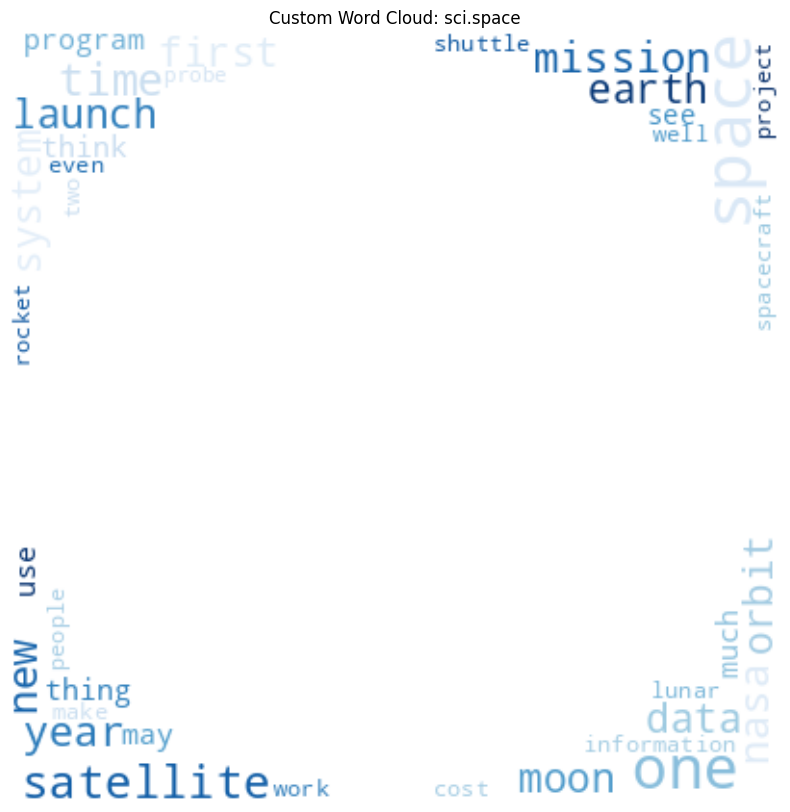

In [19]:
# TODO: Create a custom word cloud with a mask
# Choose ONE of your categories for this visualization

selected_category = "sci.space"  # Choose one of your categories

# Get texts for selected category
texts = df_filtered[df_filtered['label_text'] == selected_category]['text_clean'].tolist()
text_combined = ' '.join(texts)

# Create word cloud with mask
wordcloud_masked = WordCloud(
    width=800,
    height=800,
    background_color='white',
    colormap='Blues',
    mask=circle_mask,
    max_words=100,
    min_font_size=10
).generate(text_combined)

# Display
plt.figure(figsize=(10, 10))
plt.imshow(wordcloud_masked, interpolation='bilinear')
plt.title(f'Custom Word Cloud: {selected_category}')
plt.axis('off')
plt.savefig('custom_wordcloud.png', dpi=150, bbox_inches='tight')
plt.show()

# Part D: Bag of Words (BoW) Representation

In [20]:
# Example: Simple Bag of Words
sample_docs = [
    "I love machine learning",
    "Machine learning is great",
    "I love deep learning too"
]

# Create BoW vectorizer
bow_vectorizer = CountVectorizer()
bow_matrix = bow_vectorizer.fit_transform(sample_docs)

# Show vocabulary
print("Vocabulary:", bow_vectorizer.get_feature_names_out())
print("\nBoW Matrix (dense):")
print(bow_matrix.toarray())

# As DataFrame
bow_df = pd.DataFrame(bow_matrix.toarray(), columns=bow_vectorizer.get_feature_names_out())
print("\nAs DataFrame:")
bow_df

Vocabulary: ['deep' 'great' 'is' 'learning' 'love' 'machine' 'too']

BoW Matrix (dense):
[[0 0 0 1 1 1 0]
 [0 1 1 1 0 1 0]
 [1 0 0 1 1 0 1]]

As DataFrame:


,deep,great,is,learning,love,machine,too
0,0,0,0,1,1,1,0
1,0,1,1,1,0,1,0
2,1,0,0,1,1,0,1


**Exercise D.1: Create BoW for Your Dataset**

In [21]:
# TODO: Create a Bag of Words representation for your filtered dataset

bow_vectorizer_full = CountVectorizer(
    max_features=1000,
    min_df=5,
    max_df=0.95
)

# Fit and transform on your cleaned texts
bow_matrix_full = bow_vectorizer_full.fit_transform(df_filtered['text_clean'])

print(f"BoW Matrix shape: {bow_matrix_full.shape}")
print(f"Vocabulary size: {len(bow_vectorizer_full.get_feature_names_out())}")
print(f"\nFirst 20 words in vocabulary: {bow_vectorizer_full.get_feature_names_out()[:20]}")

BoW Matrix shape: (1777, 1000)
Vocabulary size: 1000

First 20 words in vocabulary: ['abc' 'able' 'access' 'according' 'acquired' 'activity' 'actually' 'adam'
 'add' 'addition' 'additional' 'address' 'advance' 'advanced' 'advantage'
 'aerospace' 'agency' 'ago' 'agree' 'ahl']


**Exercise D.2: Document Similarity with BoW**

In [25]:
from sklearn.metrics.pairwise import cosine_similarity
import numpy as np

# Compute similarity matrix
similarity_matrix = cosine_similarity(bow_matrix_full)

print(f"Similarity matrix shape: {similarity_matrix.shape}")

# Remove self-similarity (diagonal)
np.fill_diagonal(similarity_matrix, 0)

# Find indices of most similar pair
idx = np.unravel_index(np.argmax(similarity_matrix), similarity_matrix.shape)
most_similar_idx = idx
most_similar_score = similarity_matrix[idx]

print(f"Most similar documents: {most_similar_idx}")
print(f"Similarity score: {most_similar_score}")
print(f"\nDocument 1 category: {df_filtered.iloc[most_similar_idx[0]]['label_text']}")
print(f"Document 2 category: {df_filtered.iloc[most_similar_idx[1]]['label_text']}")


# Find most different documents
idx_min = np.unravel_index(np.argmin(similarity_matrix), similarity_matrix.shape)
print(f"Most different documents: {idx_min}")
print(f"Similarity score: {similarity_matrix[idx_min]}")


Similarity matrix shape: (1777, 1777)
Most similar documents: (np.int64(110), np.int64(345))
Similarity score: 1.0000000000000007

Document 1 category: comp.graphics
Document 2 category: comp.graphics
Most different documents: (np.int64(0), np.int64(0))
Similarity score: 0.0


In [26]:
# Show the similar documents for your analysis
print("Document 1 (first 300 chars):")
print(df_filtered.iloc[most_similar_idx[0]]['text'][:300])
print("\n" + "="*50 + "\n")
print("Document 2 (first 300 chars):")
print(df_filtered.iloc[most_similar_idx[1]]['text'][:300])

Document 1 (first 300 chars):
    Help!! I need code/package/whatever to take 3-D data and turn it into
a wireframe surface with hidden lines removed. I'm using a DOS machine, and
the code can be in ANSI C or C++, ANSI Fortran or Basic. The data I'm using
forms a rectangular grid.
   Please post your replies to the net so that o


Document 2 (first 300 chars):
:     Help!! I need code/package/whatever to take 3-D data and turn it into
: a wireframe surface with hidden lines removed. I'm using a DOS machine, and
: the code can be in ANSI C or C++, ANSI Fortran or Basic. The data I'm using
: forms a rectangular grid.
:    Please post your replies to the net


Same or different category:
The two most similar documents are from the same category. In this case, that is expected because both texts clearly discuss the same technical problem.

What makes them similar:
They are almost identical. The second document looks like a quoted or reposted version of the first one, with the same sentences about 3-D data, wireframe surface, hidden lines, and programming languages like ANSI C, C++, Fortran, and Basic. Since Bag of Words only looks at the words present and their frequencies, it gives them a very high similarity score.

Is BoW meaningful here:
Yes, BoW is meaningful here because the two documents are nearly the same, so counting shared words is enough to detect the similarity. However, this also shows a limitation of BoW, because it cannot understand whether one text is an original message and the other is just a quoted copy. It captures lexical similarity well, but not the deeper context.

# Part E: TF-IDF Representation

In [27]:
# Example: TF-IDF
sample_docs = [
    "I love machine learning",
    "Machine learning is great",
    "I love deep learning too"
]

tfidf_vectorizer = TfidfVectorizer()
tfidf_matrix = tfidf_vectorizer.fit_transform(sample_docs)

print("TF-IDF Matrix:")
tfidf_df = pd.DataFrame(
    tfidf_matrix.toarray(),
    columns=tfidf_vectorizer.get_feature_names_out()
)
tfidf_df.round(3)

TF-IDF Matrix:


,deep,great,is,learning,love,machine,too
0,0.000,0.000,0.000,0.481,0.620,0.620,0.000
1,0.000,0.584,0.584,0.345,0.000,0.445,0.000
2,0.584,0.000,0.000,0.345,0.445,0.000,0.584


In [28]:
# Compare BoW vs TF-IDF for the word "learning"
print("Word 'learning' scores:")
print(f"  BoW:    {bow_df['learning'].tolist()}")
print(f"  TF-IDF: {tfidf_df['learning'].round(3).tolist()}")
print("\nNotice: TF-IDF gives LOWER scores to common words!")

Word 'learning' scores:
  BoW:    [1, 1, 1]
  TF-IDF: [0.481, 0.345, 0.345]

Notice: TF-IDF gives LOWER scores to common words!


# Exercise E.1: TF-IDF Analysis

In [29]:
# Create TF-IDF representation
tfidf_vectorizer_full = TfidfVectorizer(
    max_features=1000,
    min_df=5,
    max_df=0.95
)

tfidf_matrix_full = tfidf_vectorizer_full.fit_transform(df_filtered['text_clean'])

print(f"TF-IDF Matrix shape: {tfidf_matrix_full.shape}")


# Function to get top TF-IDF words
def get_top_tfidf_words(category, n=10):
    """Get top n words by average TF-IDF score for a category."""

    # 1. Get indices of documents in this category
    indices = df_filtered[df_filtered['label_text'] == category].index

    # 2. Get their TF-IDF vectors
    tfidf_subset = tfidf_matrix_full[indices]

    # 3. Compute mean TF-IDF score
    mean_scores = tfidf_subset.mean(axis=0)
    mean_scores = mean_scores.A1  # convert to 1D array

    # 4. Get top words
    words = tfidf_vectorizer_full.get_feature_names_out()
    top_indices = mean_scores.argsort()[::-1][:n]

    return [words[i] for i in top_indices]


# Display top words for each category
for category in my_categories:
    top_words = get_top_tfidf_words(category, 10)
    print(f"\nTop TF-IDF words for '{category}':")
    print(top_words)

TF-IDF Matrix shape: (1777, 1000)

Top TF-IDF words for 'rec.sport.hockey':
['game', 'team', 'player', 'hockey', 'play', 'year', 'would', 'season', 'nhl', 'think']

Top TF-IDF words for 'sci.space':
['space', 'would', 'one', 'like', 'launch', 'nasa', 'orbit', 'get', 'think', 'thing']

Top TF-IDF words for 'comp.graphics':
['file', 'image', 'graphic', 'thanks', 'know', 'program', 'anyone', 'would', 'format', 'help']


Words in TF-IDF but not counts:
Some words appear in the TF-IDF top 10 but not in the simple word count top 15. For example, in rec.sport.hockey, words like "season" and "nhl" are more visible in TF-IDF. In sci.space, "launch" and "orbit" stand out more. In comp.graphics, words such as "format" and "program" appear in TF-IDF even if they were not among the most frequent words in the bar chart.

Words in counts but not TF-IDF:
On the other hand, some common words from the bar charts are less important in TF-IDF. Words like "one", "would", "like", and "get" may appear often in the word count top words, but they are less specific to the category, so TF-IDF gives them less importance.

Which method is better and why:
TF-IDF captures the topic better than simple word counts. Word counts only show the most frequent words, so they can include general words that appear in many documents. TF-IDF is more useful because it highlights words that are more specific and distinctive for each category, which makes it easier to identify the real subject of the texts.

# Part F: N-grams and Next Word Prediction

In [30]:
# Example: Extracting N-grams
from nltk import ngrams

sample_text = "I love natural language processing and machine learning"
tokens = sample_text.split()

# Bigrams (n=2)
bigrams = list(ngrams(tokens, 2))
print("Bigrams:", bigrams)

# Trigrams (n=3)
trigrams = list(ngrams(tokens, 3))
print("Trigrams:", trigrams)
# Using CountVectorizer for n-grams
bigram_vectorizer = CountVectorizer(ngram_range=(2, 2))  # Only bigrams
trigram_vectorizer = CountVectorizer(ngram_range=(3, 3))  # Only trigrams
mixed_vectorizer = CountVectorizer(ngram_range=(1, 3))    # Unigrams, bigrams, and trigrams

sample_docs = ["I love machine learning", "Machine learning is great"]

bigrams_matrix = bigram_vectorizer.fit_transform(sample_docs)
print("Bigram features:", bigram_vectorizer.get_feature_names_out())

Bigrams: [('I', 'love'), ('love', 'natural'), ('natural', 'language'), ('language', 'processing'), ('processing', 'and'), ('and', 'machine'), ('machine', 'learning')]
Trigrams: [('I', 'love', 'natural'), ('love', 'natural', 'language'), ('natural', 'language', 'processing'), ('language', 'processing', 'and'), ('processing', 'and', 'machine'), ('and', 'machine', 'learning')]
Bigram features: ['is great' 'learning is' 'love machine' 'machine learning']


# Exercise F.1: Analyze Bigrams in Your Dataset

In [31]:
# Find the top 15 most common bigrams for each category

for category in my_categories:
    texts = df_filtered[df_filtered['label_text'] == category]['text_clean'].tolist()

    # Fit vectorizer on this category
    X = bigram_vectorizer.fit_transform(texts)

    # Sum occurrences of each bigram
    sum_words = X.sum(axis=0)

    # Map bigrams to counts
    words_freq = [
        (word, sum_words[0, idx])
        for word, idx in bigram_vectorizer.vocabulary_.items()
    ]

    # Sort by frequency
    words_freq = sorted(words_freq, key=lambda x: x[1], reverse=True)

    # Take top 15
    top_bigrams = words_freq[:15]

    print(f"\nTop bigrams for '{category}':")
    for bigram, count in top_bigrams:
        print(f"  {bigram}: {int(count)}")


Top bigrams for 'rec.sport.hockey':
  power play: 138
  play scorer: 63
  san jose: 62
  third period: 58
  second period: 56
  first period: 53
  los angeles: 52
  hockey league: 52
  new jersey: 51
  tampa bay: 50
  stanley cup: 48
  last year: 41
  new york: 41
  shot save: 38
  maple leaf: 36

Top bigrams for 'sci.space':
  space station: 69
  space shuttle: 56
  anonymous ftp: 37
  commercial space: 31
  remote sensing: 30
  launch vehicle: 27
  national space: 26
  nasa ames: 24
  air force: 23
  physical universe: 23
  space technology: 21
  launch system: 20
  anyone know: 20
  black hole: 20
  space program: 20

Top bigrams for 'comp.graphics':
  image processing: 54
  file format: 42
  computer graphic: 41
  would like: 38
  thanks advance: 38
  anyone know: 35
  source code: 35
  dont know: 32
  anonymous ftp: 30
  ray tracer: 29
  virtual reality: 28
  ftp site: 27
  image file: 25
  bit image: 24
  xxxx xxxx: 22


In [32]:
class SimpleNextWordPredictor:
    def __init__(self):
        self.bigram_counts = {}  # {word1: {word2: count}}
        self.unigram_counts = {}  # {word: count}

    def train(self, texts):
        for text in texts:
            words = text.split()

            for i in range(len(words)):
                w1 = words[i]

                # Count unigrams
                self.unigram_counts[w1] = self.unigram_counts.get(w1, 0) + 1

                # Count bigrams
                if i < len(words) - 1:
                    w2 = words[i + 1]

                    if w1 not in self.bigram_counts:
                        self.bigram_counts[w1] = {}

                    self.bigram_counts[w1][w2] = self.bigram_counts[w1].get(w2, 0) + 1

    def predict_next(self, word, top_n=5):
        if word not in self.bigram_counts:
            return []

        next_words = self.bigram_counts[word]
        total = self.unigram_counts[word]

        # Compute probabilities
        probs = [(w, count / total) for w, count in next_words.items()]

        # Sort by probability
        probs = sorted(probs, key=lambda x: x[1], reverse=True)

        return probs[:top_n]


# Train on your dataset
predictor = SimpleNextWordPredictor()
predictor.train(df_filtered['text_clean'].tolist())

In [33]:
test_words = ["space", "game", "image", "nasa", "team"]

print("Next Word Predictions:")
print("=" * 40)

for word in test_words:
    predictions = predictor.predict_next(word, top_n=5)
    print(f"\n'{word}' ->")
    for next_word, prob in predictions:
        print(f"  {next_word}: {prob:.3f}")

Next Word Predictions:

'space' ->
  station: 0.078
  shuttle: 0.067
  technology: 0.024
  program: 0.024
  science: 0.021

'game' ->
  played: 0.032
  point: 0.019
  pick: 0.017
  season: 0.016
  would: 0.015

'image' ->
  processing: 0.072
  file: 0.032
  format: 0.028
  quality: 0.027
  analysis: 0.019

'nasa' ->
  ames: 0.083
  center: 0.040
  budget: 0.023
  lewis: 0.020
  spacelink: 0.020

'team' ->
  would: 0.022
  top: 0.015
  play: 0.013
  record: 0.013
  captain: 0.013


Good predictions:
Some predictions make sense, like "space → station" and "space → shuttle", which are very common in space discussions. Also, "image → processing" is a good match in computer graphics.

Bad predictions:
Some results are less useful, like "game → would" or "team → would", because "would" is too generic. Also, "game → pick" is not very clear compared to words like "season".

Limitations:
The model only looks at one word before, so it misses context. It also gives importance to very common words that are not really meaningful.

Improvement ideas:
- Use trigrams to get more context  
- Filter common words better  
- Use more advanced models like neural networks  

# Part G: Document Correlation Matrix

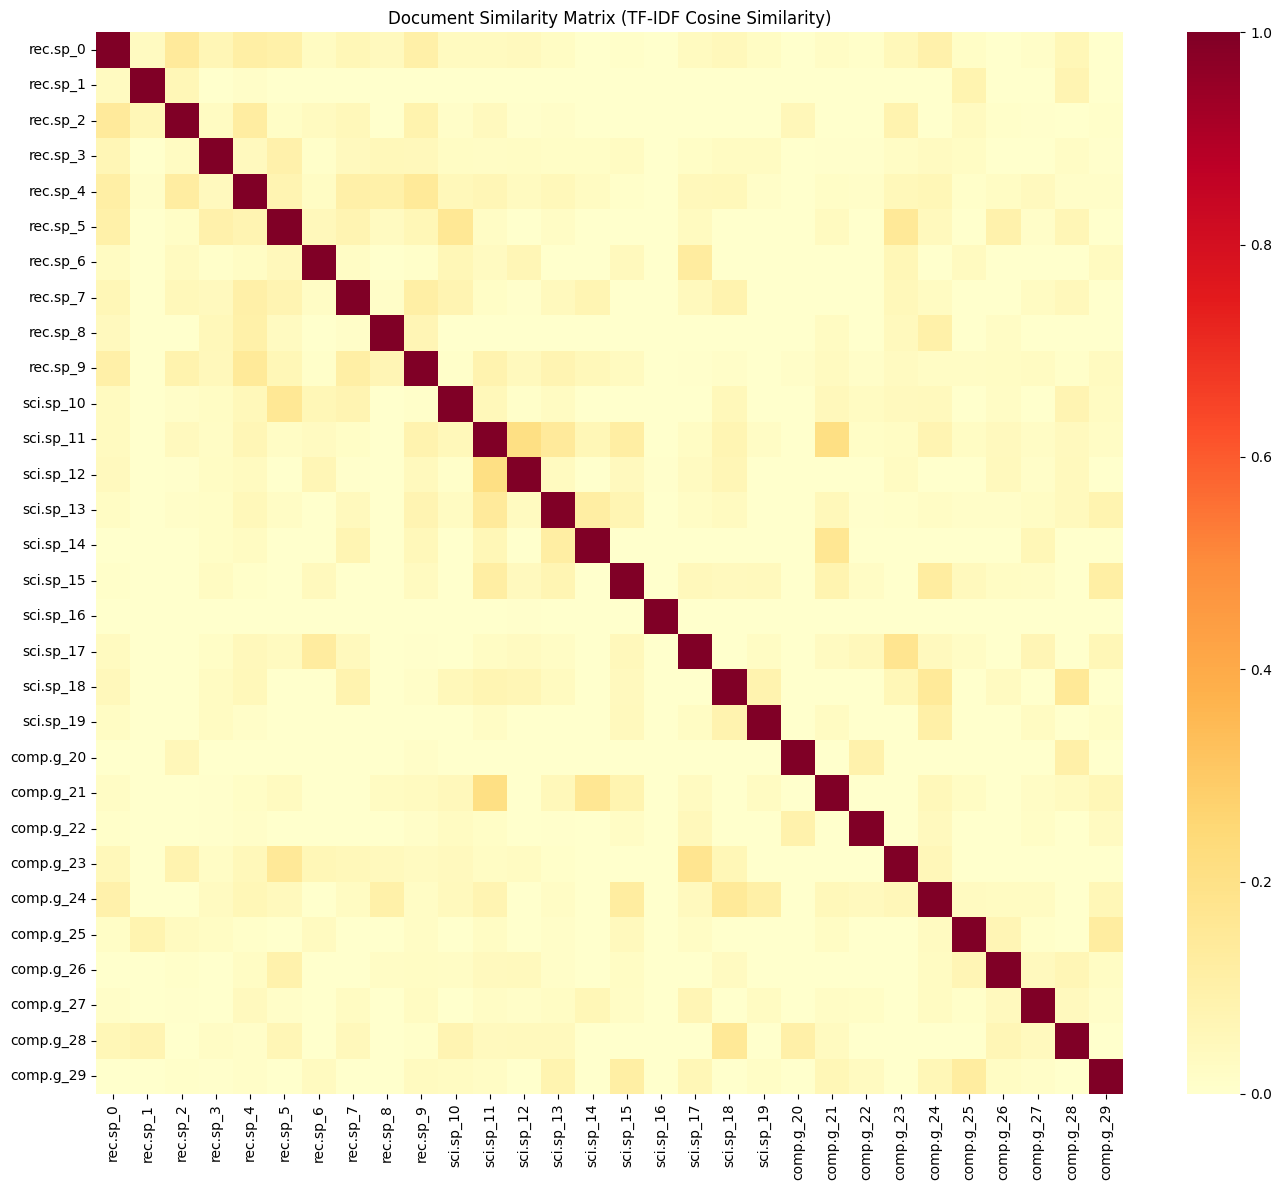

In [34]:
# Part G: Document Correlation Matrix
# Create a correlation/similarity heatmap between documents
# Sample 10 documents from each of your 3 categories (30 total)

import seaborn as sns
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

# Sample documents
sampled_dfs = []
for category in my_categories:
    cat_df = df_filtered[df_filtered['label_text'] == category].sample(n=10, random_state=42)
    sampled_dfs.append(cat_df)

df_sampled = pd.concat(sampled_dfs).reset_index(drop=True)

# Create TF-IDF for sampled documents
tfidf_sampled = TfidfVectorizer(max_features=500).fit_transform(df_sampled['text_clean'])

# Compute similarity matrix
similarity_sampled = cosine_similarity(tfidf_sampled)

# Create labels for heatmap
labels = [f"{cat[:6]}_{i}" for cat, i in zip(df_sampled['label_text'], range(len(df_sampled)))]

# Plot heatmap
plt.figure(figsize=(14, 12))
sns.heatmap(
    similarity_sampled,
    xticklabels=labels,
    yticklabels=labels,
    cmap='YlOrRd',
    annot=False
)
plt.title('Document Similarity Matrix (TF-IDF Cosine Similarity)')
plt.tight_layout()
plt.savefig('document_similarity_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

Clustering observation:
Yes, we can see that documents from the same category are grouped together. There are brighter areas along the diagonal, which means documents within the same category are more similar to each other.

Most/Least similar category pairs:
The most similar categories seem to be sci.space and comp.graphics because they share some technical vocabulary. The least similar is rec.sport.hockey compared to the others, since it is about sports and uses very different words.

Surprising similarities:
There are a few similarities between sci.space and comp.graphics documents. This is probably because both domains use some common technical terms like "data" or "system", even if the topics are different.

In [39]:
!ls -lh /content

total 1.2M
-rw-r--r-- 1 root root 203K Apr  9 08:28 custom_wordcloud.png
-rw-r--r-- 1 root root 129K Apr  9 09:00 document_similarity_heatmap.png
-rw-r--r-- 1 root root    0 Apr  9 09:59 lab3_fixed.ipynb
drwxr-xr-x 1 root root 4.0K Apr  2 13:31 sample_data
-rw-r--r-- 1 root root  86K Apr  9 08:21 top_words_by_category.png
-rw-r--r-- 1 root root 725K Apr  9 08:27 wordclouds_by_category.png


In [40]:
!rm -f /content/lab3_fixed.ipynb

In [38]:
import json
from google.colab import files

# Detect current notebook name automatically
import os

files_list = os.listdir('/content')
ipynb_files = [f for f in files_list if f.endswith('.ipynb')]
print("Found notebooks:", ipynb_files)

input_path = "/content/" + ipynb_files[0]
output_path = "/content/lab3_fixed.ipynb"

with open(input_path, "r", encoding="utf-8") as f:
    nb = json.load(f)

# 🔥 REMOVE PROBLEMATIC METADATA
if "widgets" in nb.get("metadata", {}):
    del nb["metadata"]["widgets"]

# Also clean cell metadata (extra safety)
for cell in nb.get("cells", []):
    if "metadata" in cell and "widgets" in cell["metadata"]:
        del cell["metadata"]["widgets"]

with open(output_path, "w", encoding="utf-8") as f:
    json.dump(nb, f)

print("✅ Fixed notebook saved!")

files.download(output_path)

Found notebooks: ['lab3_fixed.ipynb']


JSONDecodeError: Expecting value: line 1 column 1 (char 0)